In [ ]:
#the point of this script is for me to be able to practice python skills

#the rest of the matching to my R script is all variations of the same python syntax
#like looking at the seasons, years, etc or other variables
#see my R script in the github for this
#there is maybe some syntax that i don't have like color scales but otherwise all the same

In [60]:
#import libraries - may need to 'pip install [module]' to load the library, use pip list to view

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

In [7]:
#import files

ctd = pd.read_csv('3918_v8_bats_ctd.csv')

In [66]:
#drop na's from the depth column
ctd_filtered = ctd.dropna(subset = ['Depth'])
#select desired columns
ctd_filtered = ctd_filtered[['ISO_DateTime_UTC_deployed', 'ISO_DateTime_UTC_recovered',
                             'Latitude_deployed', 'Longitude_deployed', 'Latitude_recovered',
                             'Longitude_recovered', 'Depth', 'Pressure', 'Temperature',
                             'Salinity', 'Oxygen', 'BAC', 'Flu', 'PAR']]
#rename some columns
ctd_filtered = ctd_filtered.rename(columns = {'ISO_DateTime_UTC_deployed' : 'DateTime_deployed',
                                              'ISO_DateTime_UTC_recovered' : 'DateTime_recovered',
                                              'BAC' : 'Beam_attenuation_coeff',
                                              'Flu' : 'Fluorescence','PAR' : 'PhotosynActRadi'})

In [9]:
#change to datetime objects
ctd_filtered['DateTime_deployed'] = pd.to_datetime(ctd_filtered['DateTime_deployed'])
ctd_filtered['DateTime_recovered'] = pd.to_datetime(ctd_filtered['DateTime_recovered'])

In [11]:
#create new time-based columns
ctd_filtered['Year_deployed'] = ctd_filtered['DateTime_deployed'].dt.year
ctd_filtered['Year_recovered'] = ctd_filtered['DateTime_recovered'].dt.year
ctd_filtered['Month_deployed'] = ctd_filtered['DateTime_deployed'].dt.month
ctd_filtered['Month_recovered'] = ctd_filtered['DateTime_recovered'].dt.month
ctd_filtered['Day_deployed'] = ctd_filtered['DateTime_deployed'].dt.day
ctd_filtered['Day_recovered'] = ctd_filtered['DateTime_recovered'].dt.day
ctd_filtered['DayofYear_deployed'] = ctd_filtered['DateTime_deployed'].dt.dayofyear
ctd_filtered['DayofYear_recovered'] = ctd_filtered['DateTime_recovered'].dt.dayofyear
ctd_filtered['Time_deployed'] = ctd_filtered['DateTime_deployed'].dt.strftime('%H:%M:%S')
ctd_filtered['Time_recovered'] = ctd_filtered['DateTime_recovered'].dt.strftime('%H:%M:%S')

In [ ]:
#select desired columns in order
ctd_filtered = ctd_filtered[['DateTime_deployed', 'DateTime_recovered',
                             'Month_deployed', 'Month_recovered', 'Day_deployed',
                             'Day_recovered', 'DayofYear_deployed', 'DayofYear_recovered', 'Year_deployed',
                             'Year_recovered', 'Time_deployed', 'Time_recovered'] + 
                            [col for col in ctd_filtered.columns if col not in 
                             ['DateTime_deployed', 'DateTime_recovered', 
                              'Month_deployed', 'Month_recovered', 
                              'Day_deployed', 'Day_recovered', 
                              'DayofYear_deployed', 'DayofYear_recovered', 
                              'Year_deployed', 'Year_recovered', 
                              'Time_deployed', 'Time_recovered']]]

In [61]:
#choose just surface samples
ctd_surface = ctd_filtered[ctd_filtered['Depth'] < 100]
#separate by decade
ctd_surface_88to98 = ctd_surface[(ctd_surface['Year_deployed'] >= 1988) & (ctd_surface['Year_deployed'] <= 1998)]
ctd_surface98to08 = ctd_surface[(ctd_surface['Year_deployed'] >= 1998) & (ctd_surface['Year_deployed'] <= 2008)]
ctd_surface08to18 = ctd_surface[(ctd_surface['Year_deployed'] >= 2008) & (ctd_surface['Year_deployed'] <= 2018)]
ctd_surface18to23 = ctd_surface[(ctd_surface['Year_deployed'] >= 2018) & (ctd_surface['Year_deployed'] <= 2023)]
#make datetime objects
ctd_surface['DateTime_deployed'] = pd.to_datetime(ctd_surface['DateTime_deployed'])
ctd_surface['DateTime_recovered'] = pd.to_datetime(ctd_surface['DateTime_recovered'])

/var/folders/2j/5528n4hd4cnflw4n9fzy85b00000gn/T/ipykernel_70109/3112990802.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ctd_surface['DateTime_deployed'] = pd.to_datetime(ctd_surface['DateTime_deployed'])
/var/folders/2j/5528n4hd4cnflw4n9fzy85b00000gn/T/ipykernel_70109/3112990802.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ctd_surface['DateTime_recovered'] = pd.to_datetime(ctd_surface['DateTime_recovered'])


In [15]:
#just deep samples
ctd_deep = ctd_filtered[ctd_filtered['Depth'] > 100]

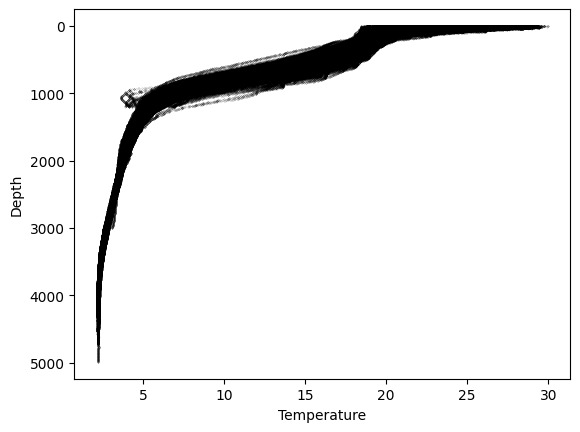

In [24]:
#thermocline
plt.scatter(ctd_filtered['Temperature'], ctd_filtered['Depth'], s = 0.025, color = 'black', alpha = 0.5)
plt.gca().invert_yaxis()
plt.xlabel('Temperature')
plt.ylabel('Depth')
plt.show()

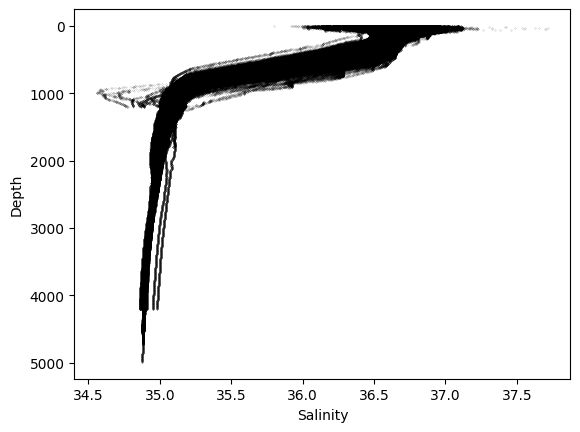

In [26]:
#halocline
plt.scatter(ctd_filtered['Salinity'], ctd_filtered['Depth'], s = 0.025, color = 'black', alpha = 0.5)
plt.gca().invert_yaxis()
plt.xlabel('Salinity')
plt.ylabel('Depth')
plt.show()

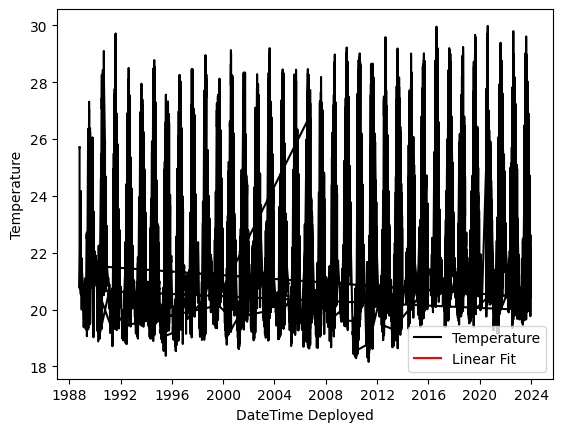

In [50]:
#temperature over time
plt.plot(ctd_surface['DateTime_deployed'], ctd_surface['Temperature'], color = 'black', label = 'Temperature')

x = sm.add_constant(ctd_surface['DateTime_deployed'].astype(np.int64) / 10**9)
y = ctd_surface['Temperature']
model = sm.OLS(y, x).fit()
predictions = model.predict(x)
plt.plot(ctd_surface['DateTime_deployed'], predictions, color = 'red', label = 'Linear Fit')

plt.xlabel('DateTime Deployed')
plt.ylabel('Temperature')
plt.legend()
plt.show()

#can't get the linear regression to show up...

In [52]:
#remove na's from temperature
ctd_surface_cl = ctd_surface.dropna(subset = ['Temperature'])

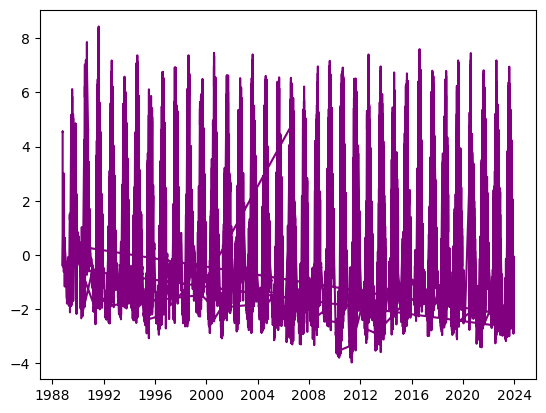

In [65]:
#detrend temperature data
ctd_surface_cl['DateTime_deployed'] = pd.to_datetime(ctd_surface_cl['DateTime_deployed'])
x = (ctd_surface_cl['DateTime_deployed'] - ctd_surface_cl['DateTime_deployed'].min()).dt.total_seconds().values.reshape(-1, 1)
y = ctd_surface_cl['Temperature'].values

Temp_model = LinearRegression()
Temp_model.fit(x, y)

ctd_surface_cl['Predicted_temp'] = Temp_model.predict(x)

ctd_surface_cl['Detrended_temp'] = ctd_surface_cl['Temperature'] - ctd_surface_cl['Predicted_temp']

plt.plot(ctd_surface_cl['DateTime_deployed'], ctd_surface_cl['Detrended_temp'], color = 'purple', label = 'Detrended temp')